In [1]:
try:
    %load_ext autoreload
    %autoreload 2
    %matplotlib widget
    print('Magic loaded')
except:
    print('No magic')

Magic loaded


In [23]:
import sys
sys.path.insert(1,"../")
from pySEA.rayTEM.elements import Element, Source, Drift, Lens, Dipole, Quadrapole, fix_ray_dims
from pySEA.rayTEM.assemblies import MicroscopeSection, load_section
from pySEA.rayTEM.postprocessing import plot2D,plot3D,plotSliceSeries
import numpy as np

In [14]:
# Construct our microscope section: drifts and lenses
elements=[
    Drift(length=1),
    Dipole(name='PD1_a', length=0, strength=0.1), Drift(length=1),
	Lens(name='PL1', strength=3.5,length=.1), Drift(length=1), 
    Quadrapole(name='PSa', strength=.5,length=.1), Drift(length=1.9),
	Lens(strength=3,length=.1), Drift(length=1),
    Quadrapole(name='PSb', strength=-.2,length=.1), Drift(length=3.9)
    ]

section=MicroscopeSection(elements=elements)
section.show_tree()

Construct our list of rays: starting positions and angles. A minimum of two (is required for auto-detection of image/diffraction planes (one normal, one at an angle, both from the same point) 

In [15]:
r0=np.asarray( [[1,1,0,0],[1,1,-1,-1]] )
r0=fix_ray_dims(r0,["x","y","xt","yt"])

Propagate and 2D plot

m: (7, 8)
r0: (2, 7) to (2, 8)
(11, 2, 7)
diffraction rays (x2) in X: must be finite x, zero y, zero xt and yt
image rays (x2) in X: must be finite xt, zero yt, zero x and y


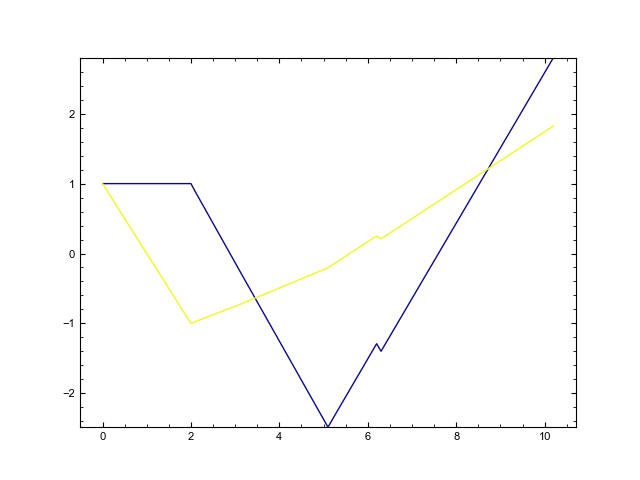

In [16]:
r1=section.propagate_ray(r0)
print(r1.shape)
plot2D(r1, section.R)

Using a `Source` we could also generate a grid of arrays to propogate.<br />
A whole series of positions and angles should make visualizing the image and diffraction planes easier.

In [17]:
section.insert(
    index=0,
    element=Source(name='OL Source', 
                   size=(2,2), np_xy=(5,5), 
                   angle=(1,1), na_xy=(3,3))
    )
section.show_tree()

Propoagate and 3D plot

m: (7, 8)
r0: (225, 7) to (225, 8)


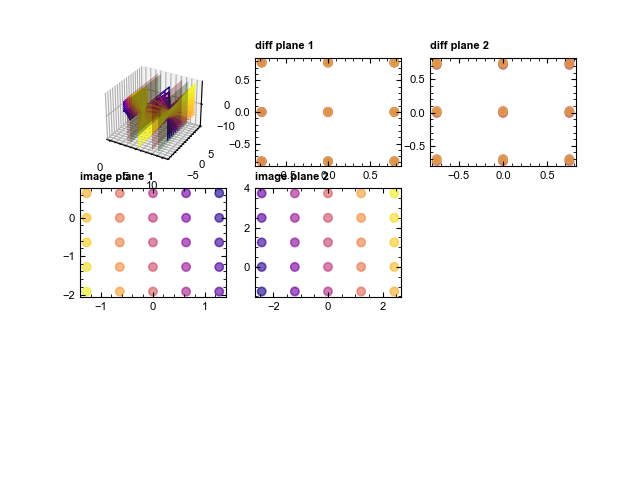

In [18]:
r1 = section.propagate_ray()
plot3D(r1, section.R)

# Save and reload

A Section can be saved and reloaded

In [21]:
import os
os.makedirs('scopes', exist_ok=True)
section.to_sea('./scopes/SDLQQ.sea')

reloaded = load_section('./scopes/SDLQQ.sea')
reloaded

name     kind     position length   strength calibrat
OL Sourc Source   None     0        0        None    
         Drift    0        1                 None    
PD1_a    Thin dip 1        0        0.1      None    
         Drift    1        1                 None    
PL1      QLens    2        0.1      3.5      None    
         Drift    2.1      1                 None    
PSa      Quad     3.1      0.1      0.5      None    
         Drift    3.2      1.9               None    
         QLens    5.1      0.1      3        None    
         Drift    5.2      1                 None    
PSb      Quad     6.2      0.1      -0.2     None    
         Drift    6.3      3.9               None

Then repropogated

m: (7, 8)
r0: (225, 7) to (225, 8)


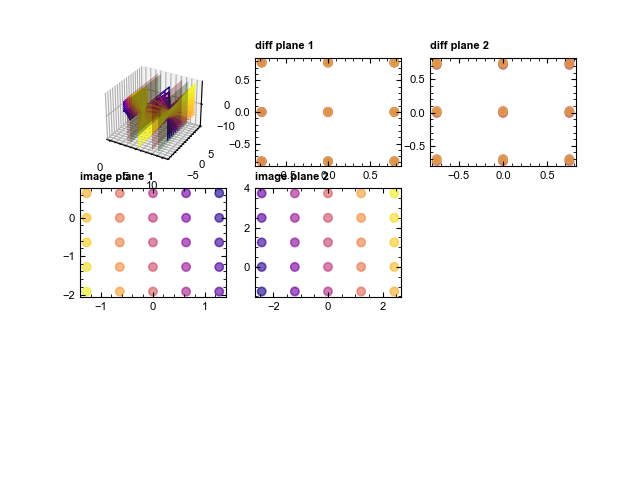

In [20]:
r1 = section.propagate_ray()
plot3D(r1, section.R)